In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df=pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\data science\sample data\House Price Prediction Dataset.csv")

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [6]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [7]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


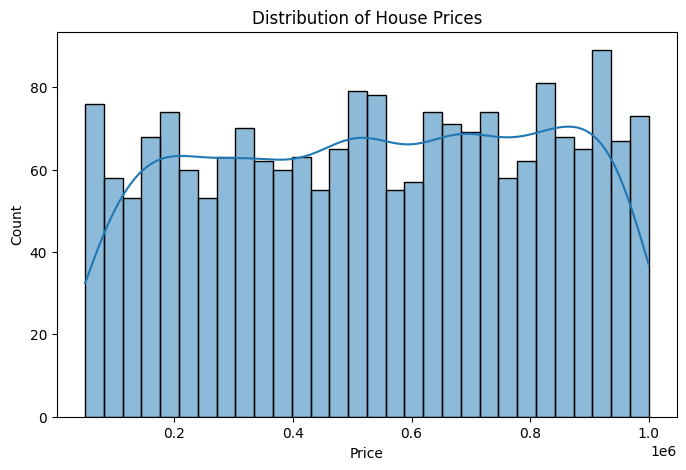

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

The selected features are Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, and Garage because they can directly affect a house's price. For example, larger houses, better locations, newer construction, and additional facilities like a garage often increase the property's value.

The Price column is the target variable because it is the value the model is designed to predict.

# ONE HOT ENCODING

In [12]:
for col in df.select_dtypes(include="object"):
    df[col].fillna(df[col].mode()[0], inplace=True)

In [13]:
for col in df.select_dtypes(exclude="object"):
    df[col].fillna(df[col].median(), inplace=True)

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


# correlation heatmap

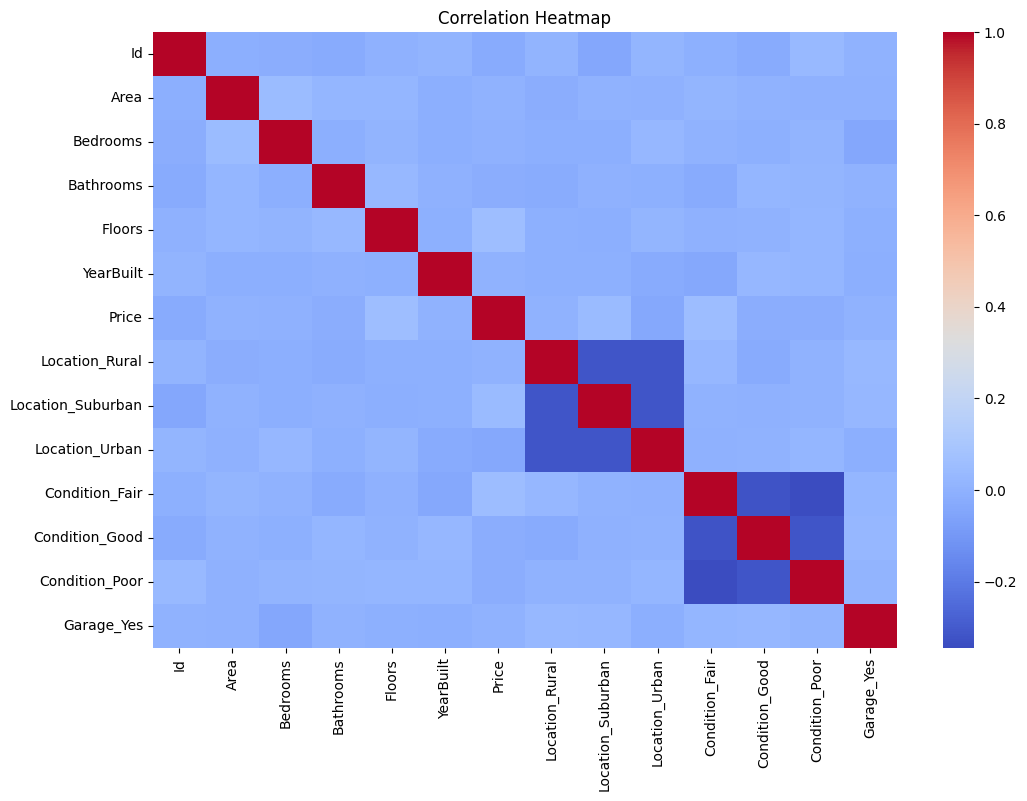

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# TRAIN TEST 

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
model = LinearRegression()

In [27]:

model.fit(X_train, y_train)

LinearRegression()

# EVALUATE 

In [28]:
from sklearn.metrics import mean_squared_error, r2_score

In [29]:
y_pred = model.predict(X_test)

In [30]:
mse = mean_squared_error(y_test, y_pred)

In [31]:
mse

np.float64(78279764120.86241)

In [32]:
rmse = np.sqrt(mse)

In [33]:
rmse

np.float64(279785.2106900263)

In [34]:
r2 = r2_score(y_test, y_pred)

In [35]:
r2

-0.006181784611834162

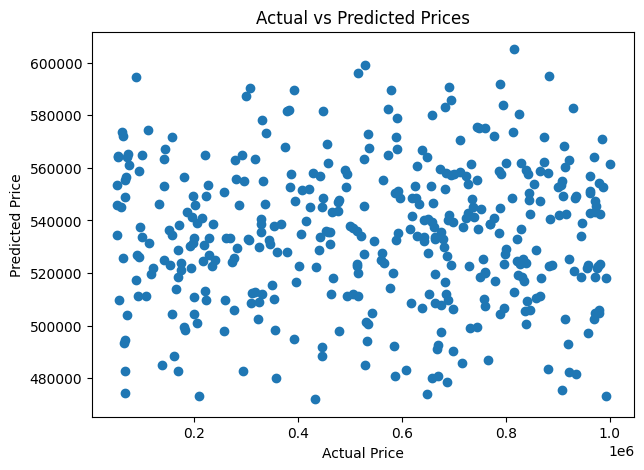

In [40]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

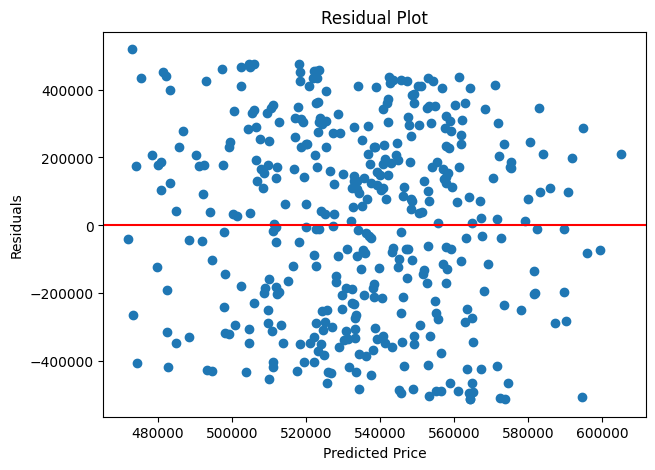

In [47]:

residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color="red")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# analyze the model coefficient

In [48]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef = coef.sort_values(by="Coefficient", ascending=False)

coef

,Feature,Coefficient
9,Condition_Fair,24049.504733
4,Floors,23582.408499
7,Location_Suburban,11110.139855
11,Condition_Poor,4389.783506
12,Garage_Yes,2218.649484
6,Location_Rural,1826.466887
5,YearBuilt,116.775334
2,Bedrooms,53.249124
1,Area,-0.484192
0,Id,-12.007473


In [49]:
coef.head()

,Feature,Coefficient
9,Condition_Fair,24049.504733
4,Floors,23582.408499
7,Location_Suburban,11110.139855
11,Condition_Poor,4389.783506
12,Garage_Yes,2218.649484


In [51]:
coef.tail()

,Feature,Coefficient
1,Area,-0.484192
0,Id,-12.007473
3,Bathrooms,-9835.704344
8,Location_Urban,-12601.589640
10,Condition_Good,-13048.175894


# compare of linear and ridge regression

In [52]:
from sklearn.linear_model import Ridge

In [53]:
ridge = Ridge(alpha=1.0)

In [57]:
ridge.fit(X_train, y_train)

Ridge()

In [59]:
ridge_pred = ridge.predict(X_test)

In [60]:
ridge_mse = mean_squared_error(y_test, ridge_pred)

In [61]:
ridge_rmse = np.sqrt(ridge_mse)

In [62]:
ridge_r2 = r2_score(y_test, ridge_pred)

In [65]:
print("Linear Regression R2 :", r2)

Linear Regression R2 : -0.006181784611834162


In [66]:
print("Ridge Regression R2 :", ridge_r2)

Ridge Regression R2 : -0.006178808380660206


In [67]:
print("Linear Regression RMSE :", rmse)

Linear Regression RMSE : 279785.2106900263


In [68]:
print("Ridge Regression RMSE :", ridge_rmse)

Ridge Regression RMSE : 279784.7968949773


Built a Linear Regression model to predict house prices.
Evaluated the model using MSE, RMSE, and R² Score.
Used correlation analysis to identify important features.
Analyzed model coefficients to understand feature impact.
Compared Ridge Regression with Linear Regression to check for performance improvement.